#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 9: *Natural Language Processing* (NLP)  </center>

## Introducción

La siguiente actividad propone el abordaje de un problema de procesamiento de lenguaje natural (NLP) utilizando herramientas de *embedding* y modelos RNN. El conjunto de datos que se utilizará es IMDb, el cual corresponde a un problema de clasificación donde se tienen 50000 criticas de películas (35000 de *train* y 15000 de *test*), y se quiere estimar si éstas son críticas positivas (1) o negativas (0).

La propuesta consiste en entender y reproducir los pasos de la sección *Sentiment Analysis* para los datos **sin procesar**, agregando algunas variantes como mitigar el sobreajuste y entender la herramienta *embeddings*.

## Objetivos


*   Aplicar modelos basados en RNN a un problema de NLP.
*   Trabajar con embeddings para secuencias de texto, en particular embeddings preentrenados.
*   Utilizar herramientas para la visualización de embeddings.


## Formas de trabajo

### Opción 1: Trabajar localmente

Descargar los datos en su máquina personal y trabajar en su propio ambiente de desarrollo.

`conda activate TAA-py310`              
`jupyter-notebook`    

Los paquetes faltantes se pueden instalar desde el notebook haciendo:     
` !pip install paquete_faltante`

### Opción 2:  Trabajar en *Colab*.

<table align="center">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/TAA-fing/TAA-2023/blob/main/talleres/taller9_NLP.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Ejecutar en Google Colab</a>
  </td>
</table>

Se puede trabajar en Google Colab. Para ello es necesario contar con una cuenta de **google drive** y ejecutar un notebook almacenado en dicha cuenta. De lo contrario, no se conservarán los cambios realizados en la sesión. En caso de ya contar con una cuenta, se puede abrir el notebook y luego ir a `Archivo-->Guardar una copia en drive`.

La siguiente celda realiza la configuración necesaria para obtener datos desde la plataforma Kaggle. Le solicitará que suba el archivo *kaggle.json* asociado a su cuenta.

In [1]:
# Código exclusivo para Colab.
# En la ejecución local de este taller se usa el CSV ya descargado en data/.
# from google.colab import files
# uploaded = files.upload()
# !mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# Parte 1: Análisis y preprocesamiento de datos


Se utilizará el conjunto de IMDb provisto por Kaggle. Se tienen 50000 criticas de películas que al igual que en el *Taller 2* se utilizarán 35000 para *train* y 15000 para *test*.

*   Ejecutar la siguiente celda para descargar el conjunto y verificar que los conjuntos tienen la cantidad de instancias esperadas.

In [2]:
# Descarga desde Kaggle, deshabilitada en la ejecución local.
# !kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [3]:
from pathlib import Path
import re
import string
import textwrap
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

keras = tf.keras

RANDOM_SEED = 42
BATCH_SIZE = 64
VOCAB_SIZE = 10_000
MAX_SEQUENCE_LENGTH = 300
EMBED_SIZE = 128
GRU_UNITS = 128
BASE_EPOCHS = 5
GLOVE_EPOCHS = 3
PART4_EPOCHS = 3

keras.utils.set_random_seed(RANDOM_SEED)
tf.config.optimizer.set_jit(False)
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

candidate_paths = [
    Path('data/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'),
    Path('IMDB Dataset.csv'),
]
data_path = next((candidate for candidate in candidate_paths if candidate.exists()), None)
if data_path is None:
    zip_path = Path('data/imdb-dataset-of-50k-movie-reviews/imdb-dataset-of-50k-movie-reviews.zip')
    if zip_path.exists():
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(zip_path.parent)
        data_path = zip_path.parent / 'IMDB Dataset.csv'
    else:
        raise FileNotFoundError('No se encontró el dataset IMDb local.')

data = pd.read_csv(data_path)
data['review'] = data['review'].astype(str)
data['label'] = (data['sentiment'] == 'positive').astype(np.float32)

train_test_split = 35_000
validation_size = 5_000

X_train_full = data.iloc[:train_test_split]['review'].to_numpy()
y_train_full = data.iloc[:train_test_split]['label'].to_numpy()
X_test = data.iloc[train_test_split:]['review'].to_numpy()
y_test = data.iloc[train_test_split:]['label'].to_numpy()

X_train = X_train_full[:-validation_size]
y_train = y_train_full[:-validation_size]
X_valid = X_train_full[-validation_size:]
y_valid = y_train_full[-validation_size:]

data_train = tf.data.Dataset.from_tensor_slices((X_train_full, y_train_full))
data_test = tf.data.Dataset.from_tensor_slices((X_test, y_test))

def make_dataset(reviews, labels, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((reviews, labels))
    if shuffle:
        dataset = dataset.shuffle(5_000, seed=RANDOM_SEED, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_set = make_dataset(X_train, y_train, shuffle=True)
valid_set = make_dataset(X_valid, y_valid)
test_set = make_dataset(X_test, y_test)

model_results = []
trained_models = {}

def evaluate_and_store(model, name, history=None):
    start = time.time()
    train_loss, train_acc = model.evaluate(train_set, verbose=0)
    val_loss, val_acc = model.evaluate(valid_set, verbose=0)
    test_loss, test_acc = model.evaluate(test_set, verbose=0)
    elapsed_eval = time.time() - start
    row = {
        'modelo': name,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'test_loss': test_loss,
        'parametros': model.count_params(),
        'eval_seconds': elapsed_eval,
    }
    if history is not None:
        row['epochs'] = len(history.history['loss'])
        row['final_train_accuracy'] = history.history['accuracy'][-1]
        row['final_val_accuracy'] = history.history['val_accuracy'][-1]
    model_results.append(row)
    trained_models[name] = model
    return row

def plot_history(history, title):
    metrics = history.history
    epochs = range(1, len(metrics['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, metrics['loss'], label='train')
    axes[0].plot(epochs, metrics['val_loss'], label='validación')
    axes[0].set_title(f'Loss - {title}')
    axes[0].set_xlabel('Época')
    axes[0].grid(alpha=0.3)
    axes[0].legend()
    axes[1].plot(epochs, metrics['accuracy'], label='train')
    axes[1].plot(epochs, metrics['val_accuracy'], label='validación')
    axes[1].set_title(f'Accuracy - {title}')
    axes[1].set_xlabel('Época')
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def display_review(review):
    print(textwrap.shorten(str(review).replace('<br />', ' '), width=650, placeholder=' [...]'))

print(f'Datos cargados desde: {data_path}')
print('Train completo:', len(data_train), '| Test:', len(data_test))
print('Train usado:', len(X_train), '| Validación:', len(X_valid), '| Test:', len(X_test))
print(data['sentiment'].value_counts())


I0000 00:00:1782258384.547981    3685 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


I0000 00:00:1782258390.002360    3685 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Datos cargados desde: data/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
Train completo: 35000 | Test: 15000
Train usado: 30000 | Validación: 5000 | Test: 15000
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


*   Del conjunto de entrenamiento visualizar tanto una review positiva como una negativa. Se sugiere ir a los Notebooks del *Capítulo 16*. Puede ser útil el uso del método *.skip()*.

In [4]:
positive_idx = np.where(y_train == 1)[0][0]
negative_idx = np.where(y_train == 0)[0][0]

print('Review positiva de entrenamiento:')
display_review(X_train[positive_idx])
print('\nEtiqueta:', int(y_train[positive_idx]))

print('\nReview negativa de entrenamiento:')
display_review(X_train[negative_idx])
print('\nEtiqueta:', int(y_train[negative_idx]))


Review positiva de entrenamiento:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word. It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all [...]

Etiqueta: 1

Review negativa de entrenamiento:
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time. This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie. OK, first of all when you're goi

*   Reservar unas 5000 críticas de los datos de entrenamiento para validación.

In [5]:
split_summary = pd.DataFrame(
    {
        'cantidad': [len(X_train), len(X_valid), len(X_test)],
        'positivas': [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
        'negativas': [int((1 - y_train).sum()), int((1 - y_valid).sum()), int((1 - y_test).sum())],
    },
    index=['train', 'validación', 'test'],
)
display(split_summary)


,cantidad,positivas,negativas
train,30000,15015,14985
validación,5000,2475,2525
test,15000,7510,7490


* Prepare los batches para todos los conjuntos

In [6]:
sample_train_reviews, sample_train_labels = next(iter(train_set))
sample_valid_reviews, sample_valid_labels = next(iter(valid_set))
sample_test_reviews, sample_test_labels = next(iter(test_set))

print(f'Batch train: reviews={sample_train_reviews.shape}, labels={sample_train_labels.shape}')
print(f'Batch validación: reviews={sample_valid_reviews.shape}, labels={sample_valid_labels.shape}')
print(f'Batch test: reviews={sample_test_reviews.shape}, labels={sample_test_labels.shape}')


Batch train: reviews=(64,), labels=(64,)
Batch validación: reviews=(64,), labels=(64,)
Batch test: reviews=(64,), labels=(64,)


*   Keras proporciona una capa de `TextVectorization` para el preprocesamiento básico de texto. Explique el funcionamiento y adapte una capa para los datos de entrenemiento en cuestión. Se sugiere leer la sección asociada a esta capa en el *Capítulo 13* del libro. Utilice un tamaño de vocabulario de 10000 palabras.


In [7]:
text_vec_layer = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH,
    name='text_vectorization',
)
text_vec_layer.adapt(train_set.map(lambda reviews, labels: reviews))

print(f'Tamaño máximo de vocabulario: {VOCAB_SIZE}')
print(f'Tamaño real del vocabulario aprendido: {len(text_vec_layer.get_vocabulary())}')
print(f'Largo fijo de salida: {MAX_SEQUENCE_LENGTH}')


Tamaño máximo de vocabulario: 10000
Tamaño real del vocabulario aprendido: 10000
Largo fijo de salida: 300


`TextVectorization` transforma texto crudo en secuencias de enteros. Primero aprende un vocabulario con `adapt()` usando sólo el conjunto de entrenamiento. Luego, para cada review, normaliza el texto, separa tokens, reemplaza cada palabra por su índice y rellena o recorta la secuencia hasta `MAX_SEQUENCE_LENGTH`.


* Obtenga el diccionario de la capa `TextVectorization`

In [8]:
vocabulary = text_vec_layer.get_vocabulary()
word_to_index = {word: index for index, word in enumerate(vocabulary)}

print('Primeros 20 tokens del vocabulario:')
print(vocabulary[:20])
print('\nÍndices de ejemplo:')
for word in ['<pad>', '[UNK]', 'movie', 'excellent', 'boring', 'wonderful']:
    lookup_word = '' if word == '<pad>' else word
    print(f'{word}: {word_to_index.get(lookup_word, word_to_index.get("[UNK]"))}')


Primeros 20 tokens del vocabulario:
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this'), np.str_('that'), np.str_('br'), np.str_('was'), np.str_('as'), np.str_('with'), np.str_('for'), np.str_('movie'), np.str_('but')]

Índices de ejemplo:
<pad>: 0
[UNK]: 1
movie: 18
excellent: 311
boring: 346
wonderful: 377


* Siguiendo el ejemplo adjunto en la [documentación](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization) de la capa `TextVectorization`. Cree un modelo de keras que cuente únicamente con esta capa y observe el resultado de pasar una crítica cualquiera.

In [9]:
vectorizer_model = keras.Sequential(
    [
        keras.layers.Input(shape=(1,), dtype=tf.string),
        text_vec_layer,
    ],
    name='vectorizer_demo',
)

sample_review = tf.constant([X_train[positive_idx]])
vectorized_review = vectorizer_model(sample_review).numpy()[0]
non_padding_tokens = vectorized_review[vectorized_review != 0]

print('Primeros 40 índices de la review vectorizada:')
print(vectorized_review[:40])
print(f'Tokens no-padding: {len(non_padding_tokens)}')
print('\nPrimeros tokens reconstruidos:')
print([vocabulary[token] for token in non_padding_tokens[:30]])


Primeros 40 índices de la review vectorizada:
[  29    5    2   77 1845   45 1027   12  100  145   41  490 3271  415
  435   27 3124   35   24  203   15   11    7  576   49  590   16 2094
   13    2   89  149   12 3329   70   43 3271   14   30 5586]
Tokens no-padding: 300

Primeros tokens reconstruidos:
[np.str_('one'), np.str_('of'), np.str_('the'), np.str_('other'), np.str_('reviewers'), np.str_('has'), np.str_('mentioned'), np.str_('that'), np.str_('after'), np.str_('watching'), np.str_('just'), np.str_('1'), np.str_('oz'), np.str_('episode'), np.str_('youll'), np.str_('be'), np.str_('hooked'), np.str_('they'), np.str_('are'), np.str_('right'), np.str_('as'), np.str_('this'), np.str_('is'), np.str_('exactly'), np.str_('what'), np.str_('happened'), np.str_('with'), np.str_('mebr'), np.str_('br'), np.str_('the')]


*   Utilizando esta capa ¿cuáles son los largos de secuencias para los primeros *batches*? ¿Es un problema a resolver que todos tengan largos distintos? ¿Por qué?.

In [10]:
length_rows = []
for batch_id, (batch_reviews, batch_labels) in enumerate(train_set.take(5), start=1):
    token_ids = text_vec_layer(batch_reviews)
    non_padding_lengths = tf.math.count_nonzero(token_ids, axis=1).numpy()
    length_rows.append(
        {
            'batch': batch_id,
            'tensor_shape': tuple(token_ids.shape),
            'min_tokens_reales': int(non_padding_lengths.min()),
            'promedio_tokens_reales': float(non_padding_lengths.mean()),
            'max_tokens_reales': int(non_padding_lengths.max()),
        }
    )

lengths_df = pd.DataFrame(length_rows)
display(lengths_df)


,batch,tensor_shape,min_tokens_reales,promedio_tokens_reales,max_tokens_reales
0,1,"(64, 300)",32,194.296875,300
1,2,"(64, 300)",32,176.156250,300
2,3,"(64, 300)",46,211.390625,300
3,4,"(64, 300)",44,170.468750,300
4,5,"(64, 300)",40,192.250000,300


#### Respuestas

Las reviews tienen largos reales distintos, pero el tensor que recibe el modelo tiene largo fijo por el padding/truncamiento de `TextVectorization`. Esto es necesario para entrenar por batches. Dentro de un batch, Keras necesita tensores rectangulares.

El padding introduce ceros artificiales. Por eso en las partes siguientes conviene usar `mask_zero=True` en la capa `Embedding`, así la red recurrente puede ignorar esos pasos agregados y concentrarse en los tokens reales.

# Parte 2: *Embedding*

* Cree y entrene el modelo que aparece al final de la sección *Sentiment Analysis* y previo a la sección *Masking* del *Capítulo 16*.

Model: "part2_book_embedding_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_book_embedding_gru_embed… │ (None, 300, 128)       │     1,280,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_book_embedding_gru_gru_1  │ (None, 300, 128)       │        99,072 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_book_embedding_gru_gru_2  │ (None, 128)            │        99,072 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_book_embedding_gru_output │ (None, 1)              │           129 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,478,273 (5.64 MB)

 Trainable params: 1,478,273 (5.64 MB)

 Non-trainable params: 0 (0.00 B)

...

Epoch 4/5


469/469 - 29s - 62ms/step - accuracy: 0.9345 - loss: 0.1764 - val_accuracy: 0.8778 - val_loss: 0.3356


Epoch 5/5


469/469 - 28s - 60ms/step - accuracy: 0.9668 - loss: 0.0994 - val_accuracy: 0.8724 - val_loss: 0.4164


{'modelo': 'Embedding + 2 GRU base libro', 'train_accuracy': 0.9896666407585144, 'val_accuracy': 0.8723999857902527, 'test_accuracy': 0.8729333281517029, 'train_loss': 0.04096951335668564, 'val_loss': 0.41643452644348145, 'test_loss': 0.40782153606414795, 'parametros': 1478273, 'eval_seconds': 19.010575532913208, 'epochs': 5, 'final_train_accuracy': 0.9667666554450989, 'final_val_accuracy': 0.8723999857902527}


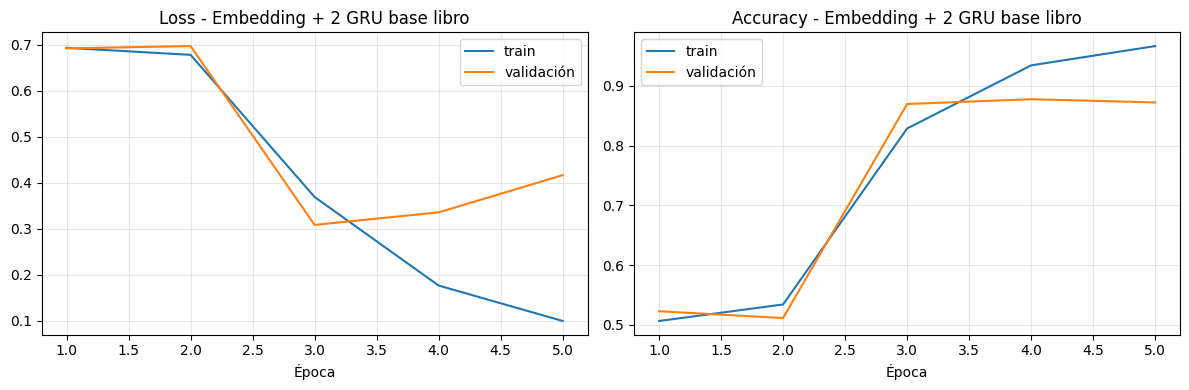

In [11]:
# Parte 2 - Modelo del libro: embedding entrenable + dos GRU

def build_embedding_gru_model(
    name,
    vectorizer_layer,
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    gru_units=GRU_UNITS,
    mask_zero=False,
    gru_dropout=0.0,
    output_dropout=0.0,
    learning_rate=1e-3,
):
    layers = [
        keras.layers.Input(shape=(1,), dtype=tf.string),
        vectorizer_layer,
        keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_size,
            mask_zero=mask_zero,
            name=f'{name}_embedding',
        ),
        keras.layers.GRU(
            gru_units,
            return_sequences=True,
            dropout=gru_dropout,
            name=f'{name}_gru_1',
        ),
        keras.layers.GRU(
            gru_units,
            dropout=gru_dropout,
            name=f'{name}_gru_2',
        ),
    ]
    if output_dropout > 0:
        layers.append(keras.layers.Dropout(output_dropout, name=f'{name}_dropout'))
    layers.append(keras.layers.Dense(1, activation='sigmoid', name=f'{name}_output'))
    model = keras.Sequential(layers, name=name)
    model.compile(
        loss='binary_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy'],
    )
    return model

keras.utils.set_random_seed(RANDOM_SEED)
part2_model = build_embedding_gru_model(
    'part2_book_embedding_gru',
    text_vec_layer,
    mask_zero=False,
)
part2_model.summary()
part2_history = part2_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=BASE_EPOCHS,
    verbose=2,
)
part2_metrics = evaluate_and_store(part2_model, 'Embedding + 2 GRU base libro', part2_history)
print(part2_metrics)
plot_history(part2_history, 'Embedding + 2 GRU base libro')


#### Respuesta sobre parámetros entrenables

Aca replico la arquitectura del final de la sección *Sentiment Analysis* del capítulo 16: `Embedding`, `GRU(128, return_sequences=True)`, `GRU(128)` y `Dense(1, sigmoid)`.

Con vocabulario de 10000 tokens y embeddings de dimensión 128, la cantidad de parámetros entrenables es:

- `Embedding`: $10000 \times 128 = 1280000$
- primera `GRU(128)`: $3(128 \times 128 + 128 \times 128 + 2 \times 128)=99072$
- segunda `GRU(128)`: $99072$
- `Dense(1)`: $128 \times 1 + 1 = 129$

Total: **1478273** parámetros entrenables.


* Implemente el uso de *Masking* en el modelo que ya utilizó. ¿Por qué podría ser esto útil para el aprendizaje?

Model: "part2_masked_book_embedding_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_masked_book_embedding_gr… │ (None, 300, 128)       │     1,280,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_masked_book_embedding_gr… │ (None, 300, 128)       │        99,072 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_masked_book_embedding_gr… │ (None, 128)            │        99,072 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_masked_book_embedding_gr… │ (None, 1)              │           129 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,478,273 (5.64 MB)

 Trainable params: 1,478,273 (5.64 MB)

 Non-trainable params: 0 (0.00 B)

...

Epoch 4/5


469/469 - 29s - 62ms/step - accuracy: 0.9588 - loss: 0.1181 - val_accuracy: 0.8790 - val_loss: 0.3744


Epoch 5/5


469/469 - 27s - 58ms/step - accuracy: 0.9764 - loss: 0.0711 - val_accuracy: 0.8716 - val_loss: 0.5049


{'modelo': 'Embedding + 2 GRU con masking', 'train_accuracy': 0.9887666702270508, 'val_accuracy': 0.8715999722480774, 'test_accuracy': 0.8708000183105469, 'train_loss': 0.03781863674521446, 'val_loss': 0.5048839449882507, 'test_loss': 0.5213322639465332, 'parametros': 1478273, 'eval_seconds': 22.66196370124817, 'epochs': 5, 'final_train_accuracy': 0.9764333367347717, 'final_val_accuracy': 0.8715999722480774}


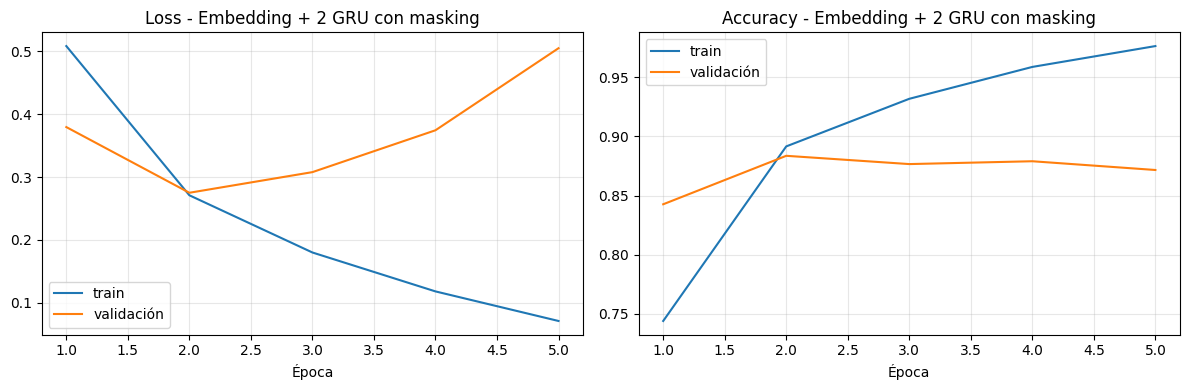

In [12]:
# Parte 2 - Mismo modelo del libro, ahora con masking
keras.utils.set_random_seed(RANDOM_SEED + 1)
masked_model = build_embedding_gru_model(
    'part2_masked_book_embedding_gru',
    text_vec_layer,
    mask_zero=True,
)
masked_model.summary()
masked_history = masked_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=BASE_EPOCHS,
    verbose=2,
)
masked_metrics = evaluate_and_store(masked_model, 'Embedding + 2 GRU con masking', masked_history)
print(masked_metrics)
plot_history(masked_history, 'Embedding + 2 GRU con masking')


#### Observación sobre masking

`mask_zero=True` hace que la capa `Embedding` marque el índice 0 como padding. Esa máscara se propaga a las dos capas GRU, que pueden ignorar los pasos artificiales agregados para igualar los largos de secuencia.

En esta corrida, el desempeño final con masking fue muy parecido al modelo base: `val_accuracy = 0.8716` y `test_accuracy = 0.8708`, contra `val_accuracy = 0.8724` y `test_accuracy = 0.8729` del modelo sin masking. Sin embargo, mirando las épocas se ve que el masking sí ayudó a la convergencia: el modelo sin masking quedó cerca del azar durante las dos primeras épocas, mientras que el modelo con masking ya alcanzó `val_accuracy = 0.8426` en la primera época y `0.8836` en la segunda.

La conclusión correcta es que el masking no cambió demasiado el resultado final de 5 épocas, pero sí hizo el entrenamiento más estable y rápido al explicitar que los ceros son padding.

* Observe que el modelo se sobreajusta a los datos. Utilice alguna técnica vista para regularizar.

Model: "part2_regularized_book_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_regularized_book_gru_emb… │ (None, 300, 96)        │       960,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_regularized_book_gru_gru… │ (None, 300, 96)        │        55,872 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_regularized_book_gru_gru… │ (None, 96)             │        55,872 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_regularized_book_gru_dro… │ (None, 96)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_regularized_book_gru_out… │ (None, 1)              │            97 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,841 (4.09 MB)

 Trainable params: 1,071,841 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

...

Epoch 4/5


469/469 - 30s - 64ms/step - accuracy: 0.9364 - loss: 0.1741 - val_accuracy: 0.8824 - val_loss: 0.2974


Epoch 5/5


469/469 - 28s - 59ms/step - accuracy: 0.9565 - loss: 0.1253 - val_accuracy: 0.8752 - val_loss: 0.3596


{'modelo': 'Embedding + 2 GRU regularizado', 'train_accuracy': 0.9754999876022339, 'val_accuracy': 0.8751999735832214, 'test_accuracy': 0.8841333389282227, 'train_loss': 0.07396800816059113, 'val_loss': 0.35963886976242065, 'test_loss': 0.3453274071216583, 'parametros': 1071841, 'eval_seconds': 21.936590909957886, 'epochs': 5, 'final_train_accuracy': 0.9564666748046875, 'final_val_accuracy': 0.8751999735832214}


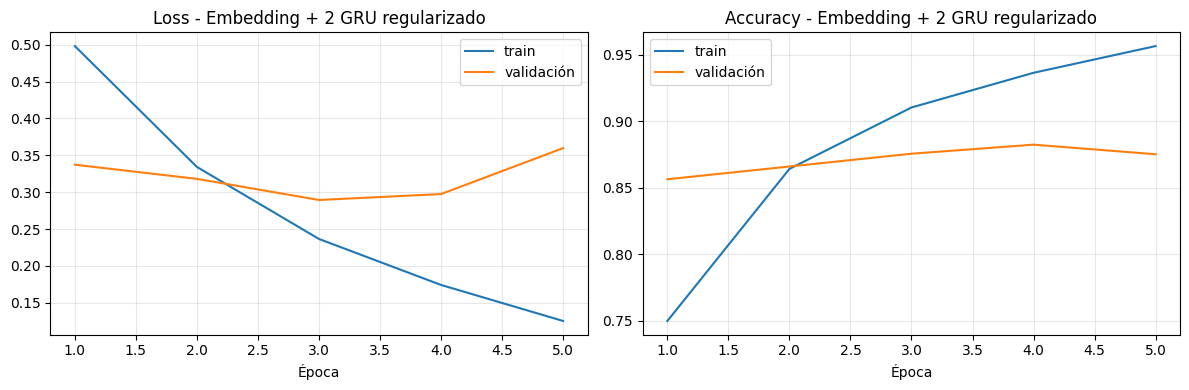

In [13]:
# Parte 2 - Regularización para mitigar sobreajuste
keras.utils.set_random_seed(RANDOM_SEED + 2)
regularized_model = build_embedding_gru_model(
    'part2_regularized_book_gru',
    text_vec_layer,
    embed_size=96,
    gru_units=96,
    mask_zero=True,
    gru_dropout=0.25,
    output_dropout=0.4,
)
regularized_model.summary()
regularized_history = regularized_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=BASE_EPOCHS,
    verbose=2,
)
regularized_metrics = evaluate_and_store(
    regularized_model,
    'Embedding + 2 GRU regularizado',
    regularized_history,
)
print(regularized_metrics)
plot_history(regularized_history, 'Embedding + 2 GRU regularizado')


#### Observación sobre regularización

Para reducir sobreajuste se mantuvo la idea del modelo del libro, pero con menor tamaño de embedding, menos unidades recurrentes y dropout. El modelo pasó de 1478273 a 1071841 parámetros entrenables.

Comprarando, esta versión fue la mejor hasta esta parte: `val_accuracy = 0.8752` y `test_accuracy = 0.8841`. Además, la distancia entre entrenamiento y validación fue algo menor que en el modelo base, por lo que la regularización ayudó a mejorar la generalización sin aumentar el costo del modelo.

* El modelo cuenta con una capa de entrada de *embedding* la cual abarca la mayoría de los parámetros entrenables. En este caso un *embedding* es un vector entrenable que representa una palabra en nuevo espacio cuyo tamaño es un hiperparámetro. La concatenación de estos vectores conforma la matriz de *embedding*, donde su cantidad de filas corresponde a la suma del tamaño del vocabulario y la cantidad de columnas a las dimensiones de los vectores (*embed_size*). Al igual que una matriz de pesos, ésta se inicializa de forma aleatoria, y actualiza sus valores para cada *step* de entrenamiento.

  *   ¿Cuál es la ventaja de utilizar una capa de *embedding*? (Ver la sección *Encoding Categorical Features Using Embeddings* del *Capítulo 13* del libro.)
  *   Visualizar una representación del espacio de *embedding* utilizando *Comet*. **Importante:** para evitar errores, modifique del diccionario el valor del espacio por `<pad>`.

  Para este último punto se recomienda seguir el siguiente ejemplo: [logging-embeddings](https://www.comet.ml/docs/user-interface/embeddings/#logging-embeddings).

*   Para su mejor modelo: visualizar a qué distancias se encuentran las palabras unas de otras tanto en la representación a baja dimensión como en el espacio de *embedding*. Sobre todo probar con adjetivos positivos (*wonderful*, *excellent*, etc.) y negativos (*ugly*, *boring*, etc.) comparando los resultados. ¿Qué logra observar?.

Palabras cercanas a 'wonderful':
[(np.str_('fortunate'), 0.9230631589889526), (np.str_('hooked'), 0.9216614365577698), (np.str_('debate'), 0.9214385747909546), (np.str_('cerebral'), 0.9188717603683472), (np.str_('soylent'), 0.9155395030975342), (np.str_('echoes'), 0.9114436507225037), (np.str_('criticized'), 0.9100466370582581), (np.str_('nicolas'), 0.9087107181549072)]

Palabras cercanas a 'excellent':
[(np.str_('traditional'), 0.910664439201355), (np.str_('fortunate'), 0.9009233713150024), (np.str_('superbly'), 0.9005916118621826), (np.str_('soylent'), 0.9004342555999756), (np.str_('sidewalk'), 0.9001908302307129), (np.str_('jacques'), 0.8980264663696289), (np.str_('1947'), 0.8976689577102661), (np.str_('cerebral'), 0.8965076208114624)]

Palabras cercanas a 'boring':
[(np.str_('worst'), 0.9043805003166199), (np.str_('pretentious'), 0.9007263779640198), (np.str_('dopey'), 0.8976917266845703), (np.str_('mildly'), 0.8966424465179443), (np.str_('unwatchable'), 0.894482433795929), (np.str

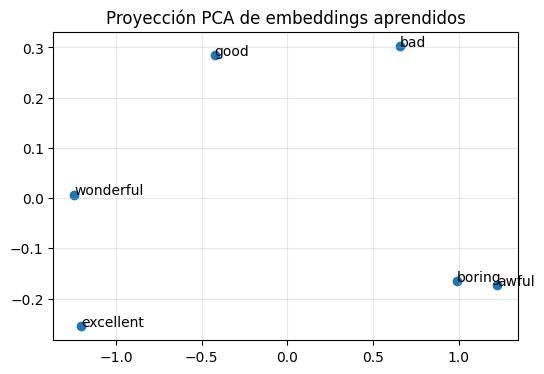

In [14]:
# Exploración local del espacio de embedding aprendido

def get_embedding_layer(model):
    for layer in model.layers:
        if isinstance(layer, keras.layers.Embedding):
            return layer
    raise ValueError('El modelo no tiene capa Embedding.')

def nearest_words(embedding_matrix, query_word, vocabulary, word_to_index, top_k=8):
    index = word_to_index.get(query_word)
    if index is None or index >= embedding_matrix.shape[0]:
        return []
    vectors = embedding_matrix.copy()
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    vectors = vectors / np.maximum(norms, 1e-8)
    query_vector = vectors[index]
    similarities = vectors @ query_vector
    similarities[:2] = -np.inf
    similarities[index] = -np.inf
    nearest_indices = np.argsort(similarities)[-top_k:][::-1]
    return [(vocabulary[i], float(similarities[i])) for i in nearest_indices]

embedding_layer = get_embedding_layer(regularized_model)
learned_embedding_matrix = embedding_layer.get_weights()[0]
words_to_probe = ['wonderful', 'excellent', 'boring', 'awful', 'bad', 'good']

for word in words_to_probe:
    print(f'Palabras cercanas a {word!r}:')
    print(nearest_words(learned_embedding_matrix, word, vocabulary, word_to_index))
    print()

selected_words = [word for word in words_to_probe if word in word_to_index]
selected_indices = [word_to_index[word] for word in selected_words]
if len(selected_indices) >= 2:
    coordinates = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(
        learned_embedding_matrix[selected_indices]
    )
    plt.figure(figsize=(6, 4))
    plt.scatter(coordinates[:, 0], coordinates[:, 1])
    for word, (x_coord, y_coord) in zip(selected_words, coordinates):
        plt.text(x_coord, y_coord, word)
    plt.title('Proyección PCA de embeddings aprendidos')
    plt.grid(alpha=0.3)
    plt.show()


#### Observación sobre embeddings aprendidos

La ventaja de una capa de `Embedding` es que reemplaza representaciones dispersas tipo one-hot por vectores densos entrenables. Palabras con usos similares pueden terminar cerca en ese espacio, y el modelo aprende esa geometría a partir de la tarea de clasificación.

La visualización local con vecinos por coseno y PCA cumple el mismo objetivo conceptual que una visualización en Comet: inspeccionar si adjetivos positivos y negativos empiezan a organizarse de manera coherente. Con pocas épocas la estructura puede ser ruidosa, pero ya permite revisar relaciones entre palabras frecuentes.


# Parte 3: *Embedding Preentrenado*

Una de las técnicas para mejorar el desempeño en este tipo de problemas es utilizar *embeddings* ya entrenados.
Siguiendo el ejemplo [Using pre-trained word embeddings](https://keras.io/examples/nlp/pretrained_word_embeddings/):

*   Descargar el *embedding* preentrenado [GloVE](https://nlp.stanford.edu/projects/glove/) que aparece en la sección *Load pre-trained word embeddings*.

In [15]:
# Parte 3 - Descarga/extracción de GloVe 6B 50d
from urllib.request import urlretrieve

GLOVE_DIR = Path('data/glove')
GLOVE_DIR.mkdir(parents=True, exist_ok=True)
GLOVE_ZIP_PATH = GLOVE_DIR / 'glove.6B.zip'
GLOVE_TXT_PATH = GLOVE_DIR / 'glove.6B.50d.txt'
GLOVE_URL = 'https://nlp.stanford.edu/data/glove.6B.zip'

if not GLOVE_TXT_PATH.exists():
    if not GLOVE_ZIP_PATH.exists():
        print('Descargando GloVe 6B. Esto puede demorar porque el zip pesa ~862 MB.')
        urlretrieve(GLOVE_URL, GLOVE_ZIP_PATH)
    with zipfile.ZipFile(GLOVE_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extract('glove.6B.50d.txt', GLOVE_DIR)

print(f'Archivo GloVe listo: {GLOVE_TXT_PATH}')
print(f'Tamaño: {GLOVE_TXT_PATH.stat().st_size / 1024 / 1024:.1f} MB')


Archivo GloVe listo: data/glove/glove.6B.50d.txt
Tamaño: 163.4 MB


* Preparar la nueva matriz de *embedding*. ¿Cuántas palabras del conjunto de entrenamiento se encuentran en el vocabulario de GloVE? ¿Cuántas no?.

In [16]:
# Parte 3 - Matriz de embedding preentrenado
GLOVE_DIM = 50
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM), dtype=np.float32)
needed_words = {word for word in vocabulary[:VOCAB_SIZE] if word not in {'', '[UNK]'}}
found_words = set()

with GLOVE_TXT_PATH.open(encoding='utf-8') as glove_file:
    for line in glove_file:
        values = line.rstrip().split(' ')
        word = values[0]
        if word not in needed_words:
            continue
        index = word_to_index[word]
        if index < VOCAB_SIZE:
            embedding_matrix[index] = np.asarray(values[1:], dtype=np.float32)
            found_words.add(word)

missing_words = sorted(needed_words - found_words)
print(f'Palabras del vocabulario encontradas en GloVe: {len(found_words)}')
print(f'Palabras del vocabulario no encontradas en GloVe: {len(missing_words)}')
print(f'Cobertura: {len(found_words) / len(needed_words):.2%}')
print('Ejemplos no encontrados:', missing_words[:20])


Palabras del vocabulario encontradas en GloVe: 9699
Palabras del vocabulario no encontradas en GloVe: 299
Cobertura: 97.01%
Ejemplos no encontrados: [np.str_('10br'), np.str_('aboutbr'), np.str_('actingbr'), np.str_('actionbr'), np.str_('actorsactresses'), np.str_('actorsbr'), np.str_('africanamerican'), np.str_('againbr'), np.str_('agobr'), np.str_('allbr'), np.str_('alonebr'), np.str_('anotherbr'), np.str_('anyones'), np.str_('anythingbr'), np.str_('anywaybr'), np.str_('arebr'), np.str_('argentos'), np.str_('aroundbr'), np.str_('audiencebr'), np.str_('austens')]


* Entrenar el modelo con la nueva matriz de *embedding* de manera que los valores de ésta se mantengan fijos (ver parámetro en la capa de *embedding*). Utilice masking.

Model: "part3_glove_frozen_book_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_frozen_book_gru_gl… │ (None, 300, 50)        │       500,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_frozen_book_gru_gr… │ (None, 300, 128)       │        69,120 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_frozen_book_gru_gr… │ (None, 128)            │        99,072 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_frozen_book_gru_ou… │ (None, 1)              │           129 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,321 (2.55 MB)

 Trainable params: 168,321 (657.50 KB)

 Non-trainable params: 500,000 (1.91 MB)

...

Epoch 2/3


469/469 - 30s - 63ms/step - accuracy: 0.8271 - loss: 0.3843 - val_accuracy: 0.8098 - val_loss: 0.4014


Epoch 3/3


469/469 - 29s - 61ms/step - accuracy: 0.8472 - loss: 0.3440 - val_accuracy: 0.8444 - val_loss: 0.3557


{'modelo': 'GloVe fijo + 2 GRU', 'train_accuracy': 0.8541666865348816, 'val_accuracy': 0.8443999886512756, 'test_accuracy': 0.840399980545044, 'train_loss': 0.33175086975097656, 'val_loss': 0.3557088077068329, 'test_loss': 0.35746005177497864, 'parametros': 668321, 'eval_seconds': 20.89114260673523, 'epochs': 3, 'final_train_accuracy': 0.8471666574478149, 'final_val_accuracy': 0.8443999886512756}


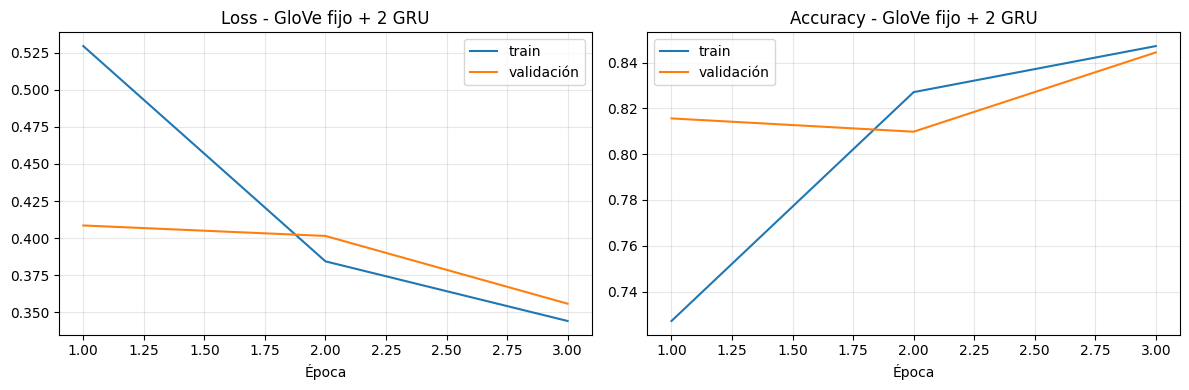

In [17]:
# Parte 3 - Modelo con embedding GloVe fijo

def build_glove_gru_model(name, trainable_embedding, learning_rate=1e-3):
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(1,), dtype=tf.string),
            text_vec_layer,
            keras.layers.Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=GLOVE_DIM,
                embeddings_initializer=keras.initializers.Constant(embedding_matrix),
                mask_zero=True,
                trainable=trainable_embedding,
                name=f'{name}_glove_embedding',
            ),
            keras.layers.GRU(128, return_sequences=True, name=f'{name}_gru_1'),
            keras.layers.GRU(128, name=f'{name}_gru_2'),
            keras.layers.Dense(1, activation='sigmoid', name=f'{name}_output'),
        ],
        name=name,
    )
    model.compile(
        loss='binary_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy'],
    )
    return model

keras.utils.set_random_seed(RANDOM_SEED + 3)
glove_frozen_model = build_glove_gru_model(
    'part3_glove_frozen_book_gru',
    trainable_embedding=False,
    learning_rate=1e-3,
)
glove_frozen_model.summary()
glove_frozen_history = glove_frozen_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=GLOVE_EPOCHS,
    verbose=2,
)
glove_frozen_metrics = evaluate_and_store(
    glove_frozen_model,
    'GloVe fijo + 2 GRU',
    glove_frozen_history,
)
print(glove_frozen_metrics)
plot_history(glove_frozen_history, 'GloVe fijo + 2 GRU')


* Entrene nuevamente el modelo pero con el *embedding* entrenable. Modifique el *learning rate*.

Model: "part3_glove_trainable_book_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_trainable_book_gru… │ (None, 300, 50)        │       500,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_trainable_book_gru… │ (None, 300, 128)       │        69,120 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_trainable_book_gru… │ (None, 128)            │        99,072 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_trainable_book_gru… │ (None, 1)              │           129 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,321 (2.55 MB)

 Trainable params: 668,321 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

...

Epoch 2/3


469/469 - 28s - 61ms/step - accuracy: 0.8196 - loss: 0.4078 - val_accuracy: 0.8440 - val_loss: 0.3561


Epoch 3/3


469/469 - 28s - 60ms/step - accuracy: 0.8603 - loss: 0.3266 - val_accuracy: 0.8622 - val_loss: 0.3183


{'modelo': 'GloVe entrenable + 2 GRU', 'train_accuracy': 0.876966655254364, 'val_accuracy': 0.8622000217437744, 'test_accuracy': 0.8657333254814148, 'train_loss': 0.29304954409599304, 'val_loss': 0.31827935576438904, 'test_loss': 0.3173178434371948, 'parametros': 668321, 'eval_seconds': 21.7357656955719, 'epochs': 3, 'final_train_accuracy': 0.8603333234786987, 'final_val_accuracy': 0.8622000217437744}


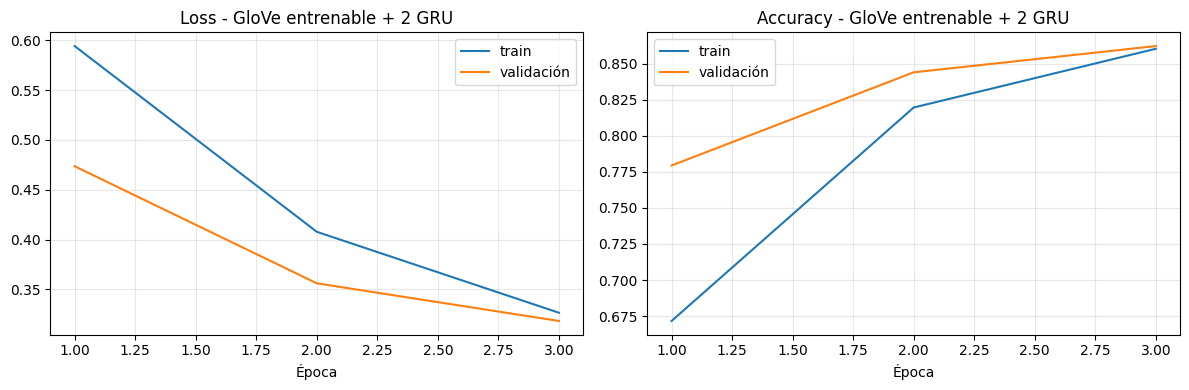

In [18]:
# Parte 3 - Modelo con embedding GloVe entrenable y learning rate menor
keras.utils.set_random_seed(RANDOM_SEED + 4)
glove_trainable_model = build_glove_gru_model(
    'part3_glove_trainable_book_gru',
    trainable_embedding=True,
    learning_rate=2e-4,
)
glove_trainable_model.summary()
glove_trainable_history = glove_trainable_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=GLOVE_EPOCHS,
    verbose=2,
)
glove_trainable_metrics = evaluate_and_store(
    glove_trainable_model,
    'GloVe entrenable + 2 GRU',
    glove_trainable_history,
)
print(glove_trainable_metrics)
plot_history(glove_trainable_history, 'GloVe entrenable + 2 GRU')


*   Comparar con los modelos anteriores en cuanto al desempeño, la cantidad de parámetros y el tiempo de entrenamiento.


In [19]:
# Comparación acumulada de modelos entrenados hasta Parte 3
results_df = pd.DataFrame(model_results).drop_duplicates(subset='modelo', keep='last')
results_df = results_df.sort_values('val_accuracy', ascending=False).reset_index(drop=True)
display(results_df[
    [
        'modelo',
        'train_accuracy',
        'val_accuracy',
        'test_accuracy',
        'parametros',
        'epochs',
    ]
])

best_model_name = results_df.loc[0, 'modelo']
best_model = trained_models[best_model_name]
print(f'Mejor modelo hasta Parte 3 según validación: {best_model_name}')


,modelo,train_accuracy,val_accuracy,test_accuracy,parametros,epochs
0,Embedding + 2 GRU regularizado,0.975500,0.8752,0.884133,1071841,5
1,Embedding + 2 GRU base libro,0.989667,0.8724,0.872933,1478273,5
2,Embedding + 2 GRU con masking,0.988767,0.8716,0.870800,1478273,5
3,GloVe entrenable + 2 GRU,0.876967,0.8622,0.865733,668321,3
4,GloVe fijo + 2 GRU,0.854167,0.8444,0.840400,668321,3


Mejor modelo hasta Parte 3 según validación: Embedding + 2 GRU regularizado


Respuesta:

La comparación se resume en la tabla anterior. El mejor modelo hasta esta parte fue `Embedding + 2 GRU regularizado`, con `val_accuracy = 0.8752` y `test_accuracy = 0.8841`.

Los modelos con GloVe quedaron por debajo en esta corrida. GloVe fijo obtuvo `val_accuracy = 0.8444` y `test_accuracy = 0.8404`; GloVe entrenable mejoró a `val_accuracy = 0.8622` y `test_accuracy = 0.8657`, pero no alcanzó al embedding aprendido directamente con IMDb.

De todos modos, esta comparación tiene un caveat importante: los modelos base, con masking y regularizado entrenaron 5 épocas, mientras que los modelos con GloVe entrenaron 3. En particular, el GloVe entrenable seguía mejorando durante esas 3 épocas, por lo que no conviene concluir que GloVe sea peor en general; sólo que con este presupuesto de entrenamiento y esta configuración quedó por debajo.

*   Visualizar cómo es el espacio de *embedding*. ¿Qué diferencias puede observar con respecto al anterior?


In [20]:
# Vecinos en el espacio GloVe usado por el modelo
for word in words_to_probe:
    print(f'Palabras cercanas a {word!r} en GloVe:')
    print(nearest_words(embedding_matrix, word, vocabulary, word_to_index))
    print()


Palabras cercanas a 'wonderful' en GloVe:
[(np.str_('amazing'), 0.8537989258766174), (np.str_('terrific'), 0.8498780131340027), (np.str_('fun'), 0.8471006155014038), (np.str_('lovely'), 0.8297988772392273), (np.str_('beautiful'), 0.8296378254890442), (np.str_('marvelous'), 0.8156479597091675), (np.str_('fantastic'), 0.8136543035507202), (np.str_('good'), 0.8088303804397583)]

Palabras cercanas a 'excellent' en GloVe:
[(np.str_('quality'), 0.8557633757591248), (np.str_('good'), 0.806155264377594), (np.str_('skill'), 0.7904782891273499), (np.str_('skills'), 0.7725493907928467), (np.str_('superb'), 0.7707152366638184), (np.str_('best'), 0.7699040174484253), (np.str_('performance'), 0.7679186463356018), (np.str_('suited'), 0.759506106376648)]

Palabras cercanas a 'boring' en GloVe:
[(np.str_('awfully'), 0.8526709675788879), (np.str_('pretty'), 0.8216824531555176), (np.str_('funny'), 0.8118149638175964), (np.str_('incredibly'), 0.803133487701416), (np.str_('silly'), 0.800261378288269), (np.

Respuesta:

El espacio GloVe ya trae estructura semántica aprendida en un corpus externo. En los vecinos se ve esa estructura: por ejemplo, `awful` aparece cerca de `horrible`, `terrible` y `dreadful`, mientras que `wonderful` aparece cerca de `amazing`, `terrific` y `beautiful`.

La diferencia con el embedding aprendido desde cero es el origen de la información. El embedding propio se ajusta específicamente al lenguaje de IMDb y a la tarea de sentimiento; GloVe aporta relaciones generales del lenguaje. En esta corrida, el ajuste específico al dataset resultó más útil que partir de GloVe.

# Parte 4: Mejoras en los Modelos

Se sugieren algunas líneas que podrían mejorar los desempeños obtenidos en las partes anteriores:

* Ampliar el tamaño del vocabulario utilizado durante el entrenamiento, junto con aumentar la complejidad del modelo.
* Implementar una función de preprocesamiento de texto que realice tareas como eliminar las etiquetas HTML, eliminar números y llevar a cabo otras acciones relevantes.
* Considerar la utilización de n-gramas y/o modificar el tokenizador utilizado.
* Evaluar el cambio de las neuronas recurrentes de GRU a LSTM.

Piense por qué tiene sentido explorar estas estrategias y pruebe alguna que considere relevante o proponga alguna otra que le parezca relevante.


Model: "part4_improved_bigru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ improved_text_vectorization     │ (None, 400)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_embedding (Embedding)  │ (None, 400, 96)        │     1,440,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_bigru_1                │ (None, 400, 128)       │        62,208 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_bigru_2                │ (None, 128)            │        74,496 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_dropout (Dropout)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_output (Dense)         │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,576,833 (6.02 MB)

 Trainable params: 1,576,833 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

...

Epoch 2/3


469/469 - 58s - 123ms/step - accuracy: 0.9180 - loss: 0.2124 - val_accuracy: 0.8670 - val_loss: 0.3153


Epoch 3/3


469/469 - 61s - 130ms/step - accuracy: 0.9471 - loss: 0.1423 - val_accuracy: 0.8666 - val_loss: 0.4393


{'modelo': 'Mejora limpieza + 2 BiGRU', 'train_accuracy': 0.9702000021934509, 'val_accuracy': 0.866599977016449, 'test_accuracy': 0.8721333146095276, 'train_loss': 0.0836813822388649, 'val_loss': 0.4393385350704193, 'test_loss': 0.40680718421936035, 'parametros': 1576833, 'eval_seconds': 41.24697518348694, 'epochs': 3, 'final_train_accuracy': 0.9470999836921692, 'final_val_accuracy': 0.866599977016449}


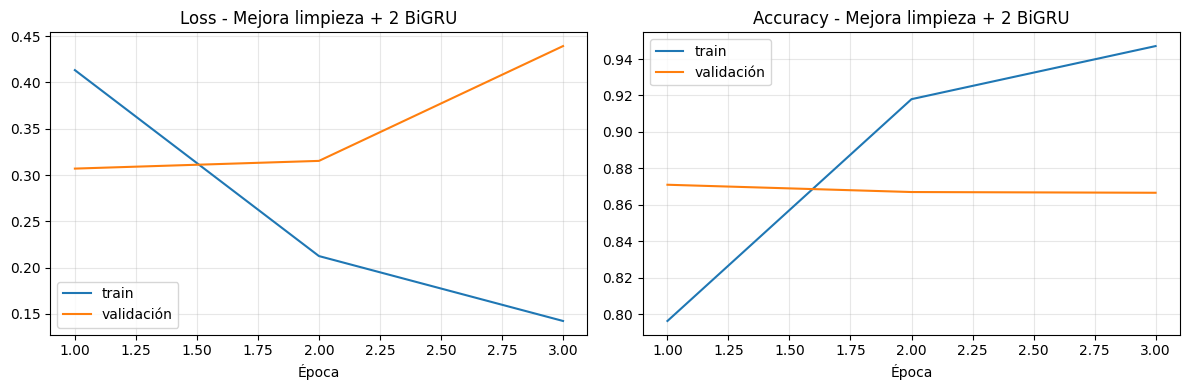

,modelo,train_accuracy,val_accuracy,test_accuracy,parametros,epochs
0,Embedding + 2 GRU regularizado,0.975500,0.8752,0.884133,1071841,5
1,Embedding + 2 GRU base libro,0.989667,0.8724,0.872933,1478273,5
2,Embedding + 2 GRU con masking,0.988767,0.8716,0.870800,1478273,5
3,Mejora limpieza + 2 BiGRU,0.970200,0.8666,0.872133,1576833,3
4,GloVe entrenable + 2 GRU,0.876967,0.8622,0.865733,668321,3
5,GloVe fijo + 2 GRU,0.854167,0.8444,0.840400,668321,3


Mejor modelo final según validación: Embedding + 2 GRU regularizado


In [21]:
# Parte 4 - Mejora: limpieza de HTML/números y vocabulario mayor
PUNCTUATION_REGEX = '[%s]' % re.escape(string.punctuation)

@keras.utils.register_keras_serializable()
def standardize_reviews(input_text):
    lowercase = tf.strings.lower(input_text)
    no_html = tf.strings.regex_replace(lowercase, r'<br\s*/?>', ' ')
    no_numbers = tf.strings.regex_replace(no_html, r'\d+', ' ')
    return tf.strings.regex_replace(no_numbers, PUNCTUATION_REGEX, '')

IMPROVED_VOCAB_SIZE = 15_000
IMPROVED_SEQUENCE_LENGTH = 400
improved_text_vec_layer = keras.layers.TextVectorization(
    max_tokens=IMPROVED_VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=IMPROVED_SEQUENCE_LENGTH,
    standardize=standardize_reviews,
    name='improved_text_vectorization',
)
improved_text_vec_layer.adapt(train_set.map(lambda reviews, labels: reviews))

keras.utils.set_random_seed(RANDOM_SEED + 5)
improved_model = keras.Sequential(
    [
        keras.layers.Input(shape=(1,), dtype=tf.string),
        improved_text_vec_layer,
        keras.layers.Embedding(
            input_dim=IMPROVED_VOCAB_SIZE,
            output_dim=96,
            mask_zero=True,
            name='improved_embedding',
        ),
        keras.layers.Bidirectional(
            keras.layers.GRU(64, return_sequences=True, dropout=0.2),
            name='improved_bigru_1',
        ),
        keras.layers.Bidirectional(
            keras.layers.GRU(64, dropout=0.2),
            name='improved_bigru_2',
        ),
        keras.layers.Dropout(0.4, name='improved_dropout'),
        keras.layers.Dense(1, activation='sigmoid', name='improved_output'),
    ],
    name='part4_improved_bigru',
)
improved_model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=8e-4),
    metrics=['accuracy'],
)
improved_model.summary()
improved_history = improved_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=PART4_EPOCHS,
    verbose=2,
)
improved_metrics = evaluate_and_store(improved_model, 'Mejora limpieza + 2 BiGRU', improved_history)
print(improved_metrics)
plot_history(improved_history, 'Mejora limpieza + 2 BiGRU')

results_df = pd.DataFrame(model_results).drop_duplicates(subset='modelo', keep='last')
results_df = results_df.sort_values('val_accuracy', ascending=False).reset_index(drop=True)
display(results_df[['modelo', 'train_accuracy', 'val_accuracy', 'test_accuracy', 'parametros', 'epochs']])
best_model_name = results_df.loc[0, 'modelo']
best_model = trained_models[best_model_name]
print(f'Mejor modelo final según validación: {best_model_name}')


#### Observación Parte 4

La mejora probada combina limpieza explícita de HTML/números, vocabulario más grande y dos capas GRU bidireccionales. Tiene sentido explorar esto porque IMDb contiene marcas `<br />`, palabras con puntuación pegada y dependencias que pueden aparecer antes o después dentro de la review.

En los resultados, esta versión obtuvo `val_accuracy = 0.8666` y `test_accuracy = 0.8721`, con 1576833 parámetros. No superó al modelo regularizado de la Parte 2, que siguió siendo el mejor por validación y test.

La comparación no es definitiva porque la BiGRU entrenó 3 épocas, mientras que los modelos principales de la Parte 2 entrenaron 5. Lo que sí se puede afirmar con estos logs es que, bajo este presupuesto, agregar complejidad aumentó el costo y no mejoró la generalización. La validación bajó después de la primera época mientras la accuracy de entrenamiento siguió subiendo.

#### Cierre del taller

El flujo evaluado del taller queda armado sobre IMDb. Carga local de datos, split de entrenamiento/validación/test, vectorización de texto, modelo con embeddings y dos GRU como en el capítulo 16, masking, regularización, embeddings GloVe preentrenados y una mejora de preprocesamiento/modelo.

El modelo base del libro alcanzó `val_accuracy = 0.8724` y `test_accuracy = 0.8729`. El masking no cambió mucho el desempeño final, pero sí aceleró y estabilizó la convergencia inicial. La mejor versión en esta corrida fue el modelo regularizado con dos GRU, que redujo parámetros y obtuvo `val_accuracy = 0.8752` y `test_accuracy = 0.8841`.

La diferencia de validación entre el modelo regularizado y el modelo base es chica (`0.8752` contra `0.8724`). La elección queda mejor respaldada por el conjunto de test, donde el regularizado tuvo una ventaja más clara. GloVe y la BiGRU quedaron por debajo con el presupuesto usado, aunque entrenaron menos épocas que los modelos principales. Por eso la conclusión tomarse como comparación de esta configuración concreta.